# Détection de la fraude dans les transactions e-commerce par apprentissage automatique


## Introduction

La lutte contre la fraude est un enjeu majeur dans le domaine du commerce en ligne. Les plateformes e-commerce sont régulièrement confrontées à des tentatives de fraude lors des transactions : usurpation d'identité, paiements suspects, comportements anormaux, etc.  
Face à la multiplication de ces attaques, l’utilisation de techniques d’apprentissage automatique (machine learning) s’impose comme une solution efficace et scalable.

Ce projet s'inscrit dans le cadre d’un mémoire de fin d’études en data science. L’objectif est de construire un modèle capable de détecter automatiquement les transactions frauduleuses à partir d’un jeu de données réaliste fourni par la société **Vesta**, spécialiste de la protection contre la fraude e-commerce.

Nous allons suivre une démarche en plusieurs étapes :
1. **Chargement et exploration du jeu de données**
2. **Visualisation et analyse exploratoire**
3. **Prétraitement et nettoyage**
4. **Construction de modèles de classification**
5. **Évaluation et interprétation des résultats**

Ce travail a pour ambition non seulement de détecter la fraude avec des algorithmes performants, mais aussi de proposer une méthodologie claire et reproductible, adaptée à des cas réels dans le secteur e-commerce.


## Importation des bibliothèques

Avant de commencer le chargement de données, nous importons l’ensemble des bibliothèques nécessaires à ce projet.

In [ ]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import recall_score, precision_score, f1_score
from sklearn.ensemble import IsolationForest


from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline


import lightgbm as lgb
import xgboost as xgb
from xgboost import XGBClassifier

# Réglages d’affichage
pd.set_option('display.max_columns', 100)
sns.set(style="whitegrid")


## 1. Chargement et fusion des jeux de données

Dans cette première étape, nous chargeons les deux fichiers CSV fournis par la compétition IEEE-CIS Fraud Detection : `train_transaction.csv` et `train_identity.csv`.

Le premier contient les détails des transactions, tandis que le second contient des informations sur l’identité du client et du terminal utilisé.

Ces fichiers partagent une clé commune, `TransactionID`, que nous utilisons pour fusionner les données.  
La jointure est effectuée en **left join** à partir de `train_transaction`, afin de conserver l’intégralité des transactions, même si certaines lignes n'ont pas d’informations d’identité.

Nous affichons ensuite un aperçu du jeu de données fusionné ainsi que le **taux global de fraude**, qui correspond à la proportion de transactions étiquetées comme frauduleuses (`isFraud = 1`).


In [ ]:
 from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Adapter ce chemin selon l'emplacement du dataset
chemin = '/content/drive/MyDrive/Mémoire/Base de données/'

# Chargement des données
df_transac = pd.read_csv(chemin + 'train_transaction.csv')
df_identite = pd.read_csv(chemin + 'train_identity.csv')

# Fusion
df = pd.merge(df_transac, df_identite, on="TransactionID", how="left")


# Aperçu des premières lignes
print("Dimensions du dataset fusionné :", df.shape)
display(df.head())

# Calcul du taux de fraude
taux_fraude = df['isFraud'].mean()
print(f"Taux de fraude dans le dataset : {taux_fraude:.4%}")

Dimensions du dataset fusionné : (590540, 434)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,M0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN,outlook.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,315.0,NaN,NaN,NaN,315.0,T,T,T,M0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,87.0,NaN,NaN,yahoo.com,NaN,2.0,5.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,25.0,1.0,112.0,112.0,0.0,94.0,0.0,NaN,NaN,NaN,NaN,84.0,NaN,NaN,NaN,NaN,111.0,NaN,NaN,NaN,M0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,NotFound,NaN,-480.0,New,NotFound,166.0,NaN,542.0,144.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,Android 7.0,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


Taux de fraude dans le dataset : 3.4990%


## 2. Visualisation et analyse exploratoire
### 2.1 Vue d’ensemble : types de variables et valeurs manquantes

Avant toute modélisation, il est indispensable de bien comprendre la structure du jeu de données.  
Cette section permet d’obtenir une vue globale sur les **types de variables**, la **densité d’informations disponibles** et les **taux de valeurs manquantes**.

Nous identifions ici les variables numériques, catégorielles ou mixtes, et nous analysons les colonnes fortement incomplètes pour anticiper les stratégies de nettoyage ou d’élimination.

Ce travail nous aidera aussi à mieux regrouper les colonnes par familles (comme `card`, `addr`, `C`, `D`, `M`, `V`, etc.) et à commencer à réfléchir à leur utilité possible pour la détection de fraude.


In [ ]:
# Affiche le type de chaque variable
type_series = df.dtypes.value_counts()
print("Types de variables dans le dataset :")
print(type_series)

# Statistiques globales sur les colonnes
print("\nNombre total de colonnes :", df.shape[1])
print("Nombre de lignes :", df.shape[0])

# Taux de valeurs manquantes par colonne
missing_ratio = df.isnull().mean().sort_values(ascending=False)

# Affiche les 20 colonnes avec le plus de valeurs manquantes
print("\nColonnes les plus incomplètes :")
display(missing_ratio.head(20))

# Affiche les 20 colonnes les plus complètes (mais pas 100%)
print("\nColonnes les plus proches de la complétude sans l'être totalement :")
display(missing_ratio[missing_ratio > 0].sort_values().head(20))

# Pourcentage de colonnes totalement vides
empty_cols = (missing_ratio == 1.0).sum()
print(f"\nColonnes vides à 100% : {empty_cols}")


Types de variables dans le dataset :
float64    399
object      31
int64        4
Name: count, dtype: int64

Nombre total de colonnes : 434
Nombre de lignes : 590540

Colonnes les plus incomplètes :


,0
id_24,0.991962
id_25,0.991310
id_07,0.991271
id_08,0.991271
id_21,0.991264
id_26,0.991257
id_27,0.991247
id_23,0.991247
id_22,0.991247
dist2,0.936284



Colonnes les plus proches de la complétude sans l'être totalement :


,0
V317,0.00002
V316,0.00002
V311,0.00002
V309,0.00002
V305,0.00002
V304,0.00002
V303,0.00002
V306,0.00002
V320,0.00002
V294,0.00002



Colonnes vides à 100% : 0


### 2.2 Analyse des variables de type object

Nous analysons ici les 31 variables de type `object`, c’est-à-dire les colonnes contenant du texte ou des catégories.  
Ces variables peuvent contenir des informations critiques telles que le type de carte bancaire, le domaine email du payeur, le type d'appareil utilisé, etc.

L’objectif est de :
- connaître leur nombre de modalités (valeurs distinctes),
- évaluer leur complétude,
- identifier celles qui peuvent être encodées pour la modélisation, et celles qui semblent peu informatives.

Cette étape nous permettra ensuite de décider de la stratégie de traitement pour chaque colonne : encodage, suppression, ou regroupement.

In [ ]:
# Extraire toutes les colonnes de type object
obj_cols = df.select_dtypes(include='object').columns

# Afficher leur nombre
print(f"Nombre de colonnes de type object : {len(obj_cols)}\n")

# Aperçu global : nom de la colonne + nombre de modalités + % de valeurs manquantes
obj_summary = pd.DataFrame({
    'Nb_valeurs_uniques': [df[col].nunique() for col in obj_cols],
    'Taux_valeurs_manquantes': [df[col].isnull().mean() for col in obj_cols]
}, index=obj_cols)

# Trier par nombre de modalités (du plus petit au plus grand)
obj_summary = obj_summary.sort_values(by='Nb_valeurs_uniques')

display(obj_summary)


Nombre de colonnes de type object : 31



,Nb_valeurs_uniques,Taux_valeurs_manquantes
M2,2,0.459071
M3,2,0.459071
M1,2,0.459071
id_12,2,0.755761
M8,2,0.586331
M7,2,0.586353
M6,2,0.286788
M5,2,0.593494
M9,2,0.586331
id_36,2,0.761261


### 2.3 Analyse détaillée des variables object

Dans cette étape, nous examinons plus en détail les 31 colonnes de type `object`.

Pour chaque variable :
- nous affichons le nombre de modalités distinctes,
- puis les 10 valeurs les plus fréquentes, ce qui permet d’identifier les formats, catégories dominantes, valeurs manquantes ou bruitées.

Cette exploration est essentielle pour décider du **type de traitement** à appliquer plus tard dans la phase de prétraitement (encodage label vs one-hot, suppression, ou regroupement).


In [ ]:
# Réaffiche les colonnes object si besoin
obj_cols = df.select_dtypes(include='object').columns

# Pour chaque colonne object, afficher un aperçu rapide
for col in obj_cols:
    print(f"--- {col} ---")
    print("Nombre de valeurs uniques :", df[col].nunique())
    print("Modalités les plus fréquentes :")
    print(df[col].value_counts(dropna=False).head(10))
    print("\n")


--- ProductCD ---
Nombre de valeurs uniques : 5
Modalités les plus fréquentes :
ProductCD
W    439670
C     68519
R     37699
H     33024
S     11628
Name: count, dtype: int64


--- card4 ---
Nombre de valeurs uniques : 4
Modalités les plus fréquentes :
card4
visa                384767
mastercard          189217
american express      8328
discover              6651
NaN                   1577
Name: count, dtype: int64


--- card6 ---
Nombre de valeurs uniques : 4
Modalités les plus fréquentes :
card6
debit              439938
credit             148986
NaN                  1571
debit or credit        30
charge card            15
Name: count, dtype: int64


--- P_emaildomain ---
Nombre de valeurs uniques : 59
Modalités les plus fréquentes :
P_emaildomain
gmail.com        228355
yahoo.com        100934
NaN               94456
hotmail.com       45250
anonymous.com     36998
aol.com           28289
comcast.net        7888
icloud.com         6267
outlook.com        5096
msn.com            409

### 2.4 Visualisation ciblée de variables catégorielles

Nous analysons ici visuellement certaines variables `object` parmi les plus significatives, afin de détecter des comportements anormaux associés à des cas de fraude.

Pour chaque variable, nous traçons le **taux de fraude par modalité** (ex : type de carte, type de produit, domaine email).  
Cela nous aide à identifier les valeurs les plus à risque, qui pourront être valorisées ou traitées différemment dans la modélisation.

Les variables observées ici sont :
- `ProductCD` : type de produit acheté
- `card4` : type de carte bancaire
- `card6` : type de débit (credit, debit…)
- `P_emaildomain` : domaine email du payeur


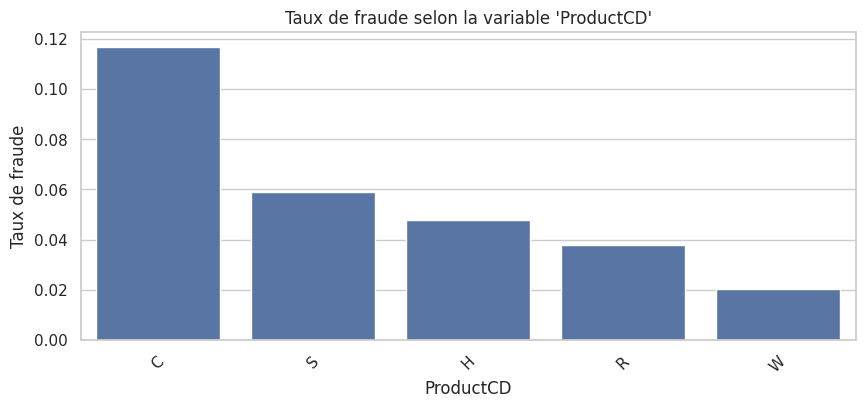

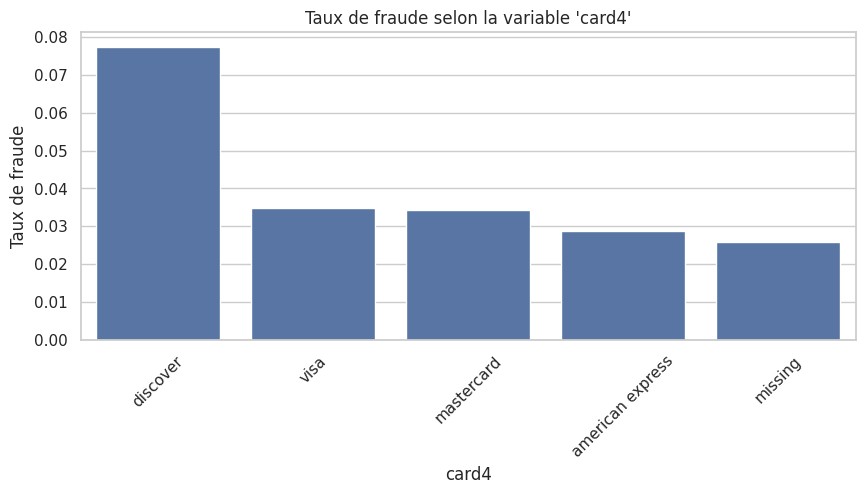

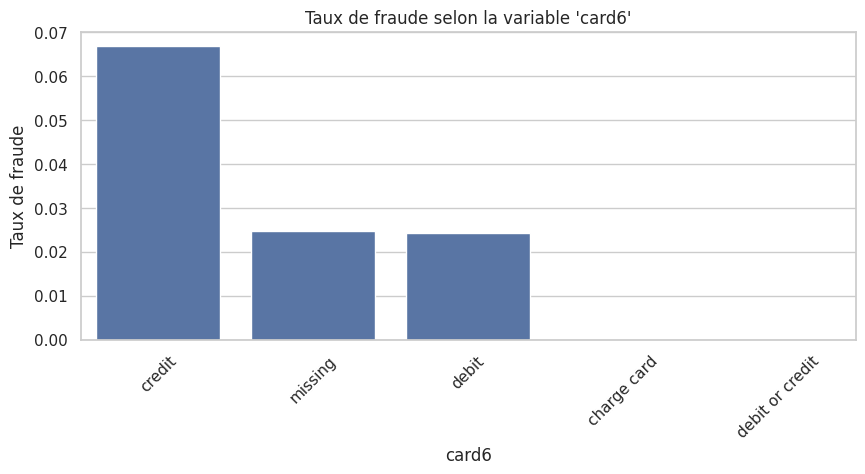

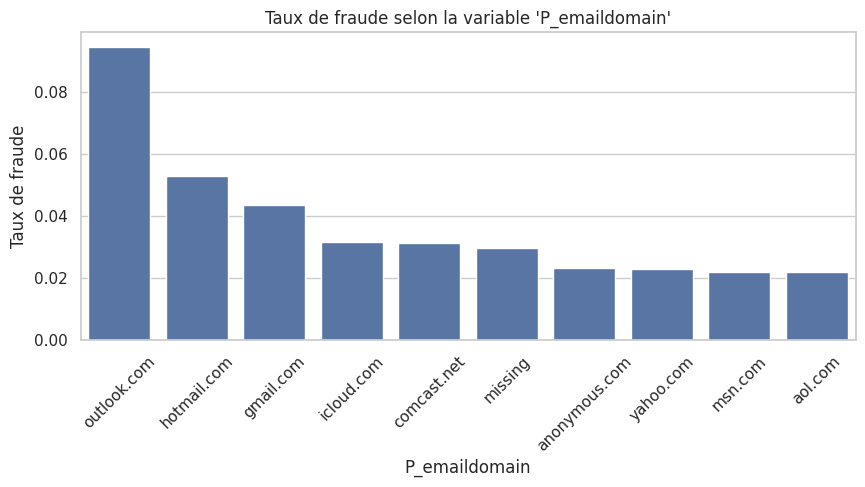

In [ ]:
# Fonction pour tracer une variable catégorielle vs isFraud
def plot_categorical_vs_fraud(df, col, top_n=10):
    # Regroupe les modalités et calcule le taux de fraude par modalité
    data = df[[col, 'isFraud']].copy()
    data[col] = data[col].fillna('missing')

    # Top N modalités les plus fréquentes
    top_vals = data[col].value_counts().head(top_n).index
    data = data[data[col].isin(top_vals)]

    # Taux de fraude par modalité
    fraud_rate = data.groupby(col)['isFraud'].mean().sort_values(ascending=False)

    # Affichage
    plt.figure(figsize=(10, 4))
    sns.barplot(x=fraud_rate.index, y=fraud_rate.values)
    plt.title(f"Taux de fraude selon la variable '{col}'")
    plt.ylabel("Taux de fraude")
    plt.xlabel(col)
    plt.xticks(rotation=45)
    plt.show()

# Variables à visualiser
cols = ['ProductCD', 'card4', 'card6', 'P_emaildomain']

for col in cols:
    plot_categorical_vs_fraud(df, col)


## 3. Préparation du jeu de données explicatif

Dans cette partie, nous construisons un sous-ensemble de données plus lisible, puis nous procédons à une phase de nettoyage et de traitement des valeurs manquantes.  
L’objectif est de rendre les données exploitables pour les futurs modèles, tout en conservant les informations les plus pertinentes et les plus compréhensibles.

### 3.1 Création d’un sous-ensemble de données réduit

Le dataset complet contient plus de 430 colonnes, dont une grande majorité sont anonymisées, redondantes ou très incomplètes.  
Pour faciliter la compréhension, nous créons ici un **DataFrame réduit** contenant uniquement :
- des variables interprétables (nommées explicitement),
- avec un **taux de valeurs manquantes raisonnable**.

Ce sous-ensemble va nous permettre d’avancer plus efficacement dans l’analyse et la modélisation, tout en gardant le dataset original intact pour d’éventuelles explorations futures.


In [ ]:
# Liste manuelle des variables conservées (explicables + taux de NaN faibles)
colonnes_retenues = [
    'TransactionID', 'TransactionDT', 'TransactionAmt', 'isFraud',
    'ProductCD', 'card1', 'card2', 'card3', 'card5', 'card4', 'card6',
    'addr1', 'addr2',
    'P_emaildomain',
    'DeviceType',
    'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9'
]

# Créer le nouveau DataFrame réduit
df_reduit = df[colonnes_retenues].copy()

# Afficher un aperçu
print(f"Dimensions du DataFrame réduit : {df_reduit.shape}")
display(df_reduit.head(10))

# Vérifier taux de valeurs manquantes dans ce sous-ensemble
taux_nan_reduit = df_reduit.isnull().mean().sort_values(ascending=False)
print("\nTaux de valeurs manquantes dans le DataFrame réduit :")
display(taux_nan_reduit)


Dimensions du DataFrame réduit : (590540, 24)


,TransactionID,TransactionDT,TransactionAmt,isFraud,ProductCD,card1,card2,card3,card5,card4,card6,addr1,addr2,P_emaildomain,DeviceType,M1,M2,M3,M4,M5,M6,M7,M8,M9
0,2987000,86400,68.5,0,W,13926,NaN,150.0,142.0,discover,credit,315.0,87.0,NaN,NaN,T,T,T,M2,F,T,NaN,NaN,NaN
1,2987001,86401,29.0,0,W,2755,404.0,150.0,102.0,mastercard,credit,325.0,87.0,gmail.com,NaN,NaN,NaN,NaN,M0,T,T,NaN,NaN,NaN
2,2987002,86469,59.0,0,W,4663,490.0,150.0,166.0,visa,debit,330.0,87.0,outlook.com,NaN,T,T,T,M0,F,F,F,F,F
3,2987003,86499,50.0,0,W,18132,567.0,150.0,117.0,mastercard,debit,476.0,87.0,yahoo.com,NaN,NaN,NaN,NaN,M0,T,F,NaN,NaN,NaN
4,2987004,86506,50.0,0,H,4497,514.0,150.0,102.0,mastercard,credit,420.0,87.0,gmail.com,mobile,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2987005,86510,49.0,0,W,5937,555.0,150.0,226.0,visa,debit,272.0,87.0,gmail.com,NaN,T,T,T,M1,F,T,NaN,NaN,NaN
6,2987006,86522,159.0,0,W,12308,360.0,150.0,166.0,visa,debit,126.0,87.0,yahoo.com,NaN,T,T,T,M0,F,F,T,T,T
7,2987007,86529,422.5,0,W,12695,490.0,150.0,226.0,visa,debit,325.0,87.0,mail.com,NaN,NaN,NaN,NaN,M0,F,F,NaN,NaN,NaN
8,2987008,86535,15.0,0,H,2803,100.0,150.0,226.0,visa,debit,337.0,87.0,anonymous.com,mobile,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2987009,86536,117.0,0,W,17399,111.0,150.0,224.0,mastercard,debit,204.0,87.0,yahoo.com,NaN,T,T,T,M0,T,T,NaN,NaN,NaN



Taux de valeurs manquantes dans le DataFrame réduit :


,0
DeviceType,0.761557
M5,0.593494
M7,0.586353
M8,0.586331
M9,0.586331
M4,0.476588
M1,0.459071
M3,0.459071
M2,0.459071
M6,0.286788


### 3.2 Exploration détaillée des modalités de chaque variable


In [ ]:
# Aperçu détaillé des colonnes dans df_reduit
for col in df_reduit.columns:
    print(f"--- {col} ---")
    print("Nombre de valeurs uniques :", df_reduit[col].nunique(dropna=False))
    print("Modalités les plus fréquentes :")
    print(df_reduit[col].value_counts(dropna=False).head(10))
    print("\n")

--- TransactionID ---
Nombre de valeurs uniques : 590540
Modalités les plus fréquentes :
TransactionID
3577539    1
2987000    1
2987001    1
2987002    1
2987003    1
2987004    1
2987005    1
2987006    1
2987007    1
2987008    1
Name: count, dtype: int64


--- TransactionDT ---
Nombre de valeurs uniques : 573349
Modalités les plus fréquentes :
TransactionDT
9474817     8
4397066     5
11576951    5
7236588     5
2073296     4
8218707     4
8218708     4
1544629     4
7337054     4
1971839     4
Name: count, dtype: int64


--- TransactionAmt ---
Nombre de valeurs uniques : 20902
Modalités les plus fréquentes :
TransactionAmt
59.00     30582
117.00    28933
107.95    23954
57.95     23600
100.00    20362
50.00     17009
49.00     15990
226.00    11704
39.00     11095
29.00     10683
Name: count, dtype: int64


--- isFraud ---
Nombre de valeurs uniques : 2
Modalités les plus fréquentes :
isFraud
0    569877
1     20663
Name: count, dtype: int64


--- ProductCD ---
Nombre de valeurs un

### 3.3 Nettoyage des valeurs manquantes

Nous procédons ici au nettoyage des valeurs manquantes dans le DataFrame réduit `df_clean`, en distinguant trois groupes de variables selon leur nature.

#### Groupe 1 : `card2`, `card3`, `card5`, `addr1`, `addr2`
Ces variables sont numériques mais représentent des catégories anonymisées (banques, régions, zones géographiques).  
Nous les convertissons en chaînes de caractères, puis remplaçons les valeurs manquantes par la modalité `"missing"`.

#### Groupe 2 : `M1` à `M9`
Ces variables sont des indicateurs binaires ou ternaires (`T`, `F`, `NaN`).  
Les `NaN` sont remplacés par une modalité explicite `"missing"` pour conserver l’information.

#### Groupe 3 : `DeviceType`, `P_emaildomain`, `card4`, `card6`
Ces variables sont catégorielles classiques.  
Les valeurs manquantes sont également remplacées par `"missing"`, ce qui permet au modèle d’exploiter cette absence comme un signal éventuel.

In [ ]:
# Création d'une copie du DataFrame réduit
df_clean = df_reduit.copy()

# Groupe 1
cat_num_cols = ['card2', 'card3', 'card5', 'addr1', 'addr2']
for col in cat_num_cols:
    df_clean[col] = df_clean[col].astype(str)
    df_clean[col] = df_clean[col].replace('nan', 'missing')

# Groupe 2
m_cols = ['M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']
for col in m_cols:
    df_clean[col] = df_clean[col].fillna('missing')

# Groupe 3
simple_cat_cols = ['DeviceType', 'P_emaildomain', 'card4', 'card6']
for col in simple_cat_cols:
    df_clean[col] = df_clean[col].fillna('missing')

# Vérification finale
print("Taux de valeurs manquantes restantes dans df_clean :")
display(df_clean.isnull().mean().sort_values(ascending=False))


Taux de valeurs manquantes restantes dans df_clean :


,0
TransactionID,0.0
TransactionDT,0.0
TransactionAmt,0.0
isFraud,0.0
ProductCD,0.0
card1,0.0
card2,0.0
card3,0.0
card5,0.0
card4,0.0


### 3.4 Traitement spécifique d'une modalité rare dans `card6`

Lors de l’analyse des modalités de la variable `card6`, nous avons observé une modalité rare : `"debit or credit"`, présente dans seulement **30 lignes** du dataset.

Afin de prendre une décision éclairée, nous avons vérifié leur lien avec la variable cible `isFraud`.  
**Résultat : aucune de ces 30 transactions n'était frauduleuse.**

Cette modalité étant :
- peu représentée (moins de 0.005% du dataset),
- redondante avec les valeurs manquantes (ambiguïté sur le type réel de carte),
- et sans lien avec la fraude,

Nous avons choisi de la remplacer par la modalité `"missing"` afin :
- d’éviter d’introduire du bruit inutile,
- de simplifier l’encodage de la variable,
- et de rendre cette modalité cohérente avec notre traitement des valeurs inconnues.


In [ ]:
# Remplacer "debit or credit" par "missing" dans card6
df_clean['card6'] = df_clean['card6'].replace('debit or credit', 'missing')

### 3.5 Encodage des variables catégorielles

Les modèles de machine learning classiques n’acceptent pas les variables textuelles.  
Nous devons donc encoder les variables catégorielles en valeurs numériques.

Ici, nous appliquons un **Label Encoding**, qui transforme chaque modalité par un entier unique.  
Cette méthode est rapide et bien tolérée par des modèles non linéaires comme les forêts aléatoires ou les gradient boosting (LightGBM, XGBoost...).

Les variables concernées par l'encodage sont :  
`ProductCD`, `card4`, `card6`, `P_emaildomain`, `DeviceType`, `M1` à `M9`, `card2`, `card3`, `card5`, `addr1`, `addr2`


In [ ]:
# Encodage LabelEncoder des variables catégorielles
cat_to_encode = [
    'ProductCD', 'card4', 'card6', 'P_emaildomain', 'DeviceType',
    'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9',
    'card2', 'card3', 'card5', 'addr1', 'addr2'
]

le = LabelEncoder()
for col in cat_to_encode:
    df_clean[col] = le.fit_transform(df_clean[col])


## 4. Construction du modèle de classification

Nous entamons ici la phase de modélisation. L’objectif est de construire des modèles capables de prédire efficacement les transactions frauduleuses à partir des variables explicatives que nous avons nettoyées et encodées.

Pour assurer une évaluation fiable et éviter tout biais, nous séparons nos données en trois ensembles distincts :
- **Ensemble d'entraînement** : utilisé pour ajuster les modèles
- **Ensemble de validation** : utilisé pour comparer différents modèles ou configurations
- **Ensemble de test** : laissé de côté jusqu'à la toute fin, pour évaluer objectivement les performances finales du modèle choisi


### 4.1 Premier modèle : Random Forest

Nous commençons avec un modèle de base robuste : la forêt aléatoire. Ce modèle permet de tester rapidement l’utilité des variables, sans nécessiter de mise à l’échelle.

#### 4.1.1 Séparation des données (train, validation, test)

Nous séparons nos données en trois parties :
- 60 % pour l'entraînement,
- 20 % pour la validation (sélection de modèle),
- 20 % pour le test (évaluation finale).


In [ ]:
# Définir X et y
X = df_clean.drop(columns=['isFraud'])
y = df_clean['isFraud']

# Étape 1 : séparer train + temp (val + test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)

# Étape 2 : séparer temp → validation + test
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Vérification des tailles
print("Entraînement :", X_train.shape)
print("Validation   :", X_valid.shape)
print("Test         :", X_test.shape)

# Vérification du taux de fraude dans chaque groupe
print("\nTaux de fraude dans chaque groupe :")
print("Train      :", y_train.mean())
print("Validation :", y_valid.mean())
print("Test       :", y_test.mean())


Entraînement : (354324, 23)
Validation   : (118108, 23)
Test         : (118108, 23)

Taux de fraude dans chaque groupe :
Train      : 0.03499057359930459
Validation : 0.0349933958749619
Test       : 0.03498492904798998


#### 4.1.2 Entraînement du modèle Random Forest

Nous entraînons ici un premier modèle de classification à l’aide de la méthode Random Forest.  
Ce modèle est robuste, facile à interpréter, et performant sur des données hétérogènes, même sans normalisation préalable.

L'entraînement est réalisé sur l'ensemble d'entraînement uniquement.


In [ ]:
# Initialisation du modèle
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Entraînement sur l'ensemble d'entraînement uniquement
rf_model.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', max_depth=10, n_jobs=-1,
                       random_state=42)

#### 4.1.3 Évaluation du modèle sur l’ensemble de validation

Nous évaluons ici les performances du modèle Random Forest sur l’ensemble de validation.  
Les métriques utilisées sont :

- **Matrice de confusion**
- **Accuracy**
- **Recall (sensibilité)** : particulièrement important dans la détection de fraude
- **F1-score**
- **AUC (Area Under the ROC Curve)** : mesure globale de la performance binaire

Nous utilisons l’ensemble de validation uniquement à cette étape. Le jeu de test est conservé pour l’évaluation finale du modèle choisi.

In [ ]:
# Prédictions
y_pred_valid = rf_model.predict(X_valid)
y_proba_valid = rf_model.predict_proba(X_valid)[:, 1]

# Matrice de confusion et rapport de classification
print("Matrice de confusion :")
print(confusion_matrix(y_valid, y_pred_valid))

print("\nRapport de classification :")
print(classification_report(y_valid, y_pred_valid, digits=4))

# AUC
auc_score = roc_auc_score(y_valid, y_proba_valid)
print(f"AUC (validation) : {auc_score:.4f}")

Matrice de confusion :
[[94688 19287]
 [ 1107  3026]]

Rapport de classification :
              precision    recall  f1-score   support

           0     0.9884    0.8308    0.9028    113975
           1     0.1356    0.7322    0.2288      4133

    accuracy                         0.8273    118108
   macro avg     0.5620    0.7815    0.5658    118108
weighted avg     0.9586    0.8273    0.8792    118108

AUC (validation) : 0.8603


**Synthèse des résultats du modèle Random Forest**

Le modèle Random Forest entraîné sur les données nettoyées et encodées donne des résultats encourageants sur l'ensemble de validation.

**Matrice de confusion :**

- 3 026 fraudes correctement détectées sur 4 133 (recall de 73.2 %)
- 19 287 transactions normales détectées à tort comme frauduleuses

**Métriques principales :**

- Accuracy : 82.7 %
- Recall (fraude) : 73.2 % → Très bon pour un premier modèle
- Précision (fraude) : 13.5 % → Beaucoup de faux positifs
- F1-score (fraude) : 22.8 %
- AUC : 0.8603 → Très bonne capacité de discrimination globale

**Interprétation :**

- Ce premier modèle détecte efficacement la majorité des fraudes, ce qui est essentiel dans un contexte e-commerce.
- Il présente toutefois une quantité importante de faux positifs, ce qui sera à corriger par la suite.
- L’évaluation a été faite uniquement sur l’ensemble de validation. Le jeu de test reste intact pour une évaluation finale future.

Ces résultats constituent une première base solide pour la suite de l'expérimentation.


#### 4.1.4 Optimisation des hyperparamètres du modèle Random Forest

Avant de tester d'autres algorithmes, nous cherchons à tirer le meilleur parti de notre modèle Random Forest actuel.

Nous appliquons ici une méthode d’optimisation par **Randomized Search**, qui permet de tester efficacement un large espace de combinaisons d’hyperparamètres, sans passer par un balayage exhaustif comme dans un Grid Search classique.

L’objectif est d’identifier des configurations qui améliorent les performances du modèle tout en préservant une bonne généralisation.

Les paramètres que nous allons explorer incluent notamment :
- le nombre d’arbres (`n_estimators`),
- la profondeur maximale (`max_depth`),
- le nombre minimal d’échantillons requis pour diviser un nœud (`min_samples_split`),
- et d’autres paramètres influents comme le `max_features` ou `class_weight`.


In [ ]:
# Définition des plages d’hyperparamètres à explorer
param_distributions = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced', 'balanced_subsample']
}

# Instanciation du modèle de base
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# Randomized Search avec validation croisée
random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_distributions,
    n_iter=10,
    scoring='roc_auc',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=2,
    error_score='raise'
)

# Entraînement du modèle sur l’ensemble d’apprentissage uniquement
random_search.fit(X_train, y_train)


Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


RandomizedSearchCV(cv=3, error_score='raise',
                   estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
                   n_jobs=2,
                   param_distributions={'class_weight': ['balanced',
                                                         'balanced_subsample'],
                                        'max_depth': [5, 10, 20, None],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='roc_auc', verbose=2)

In [ ]:
print("Meilleurs hyperparamètres trouvés :")
print(random_search.best_params_)


Meilleurs hyperparamètres trouvés :
{'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None, 'class_weight': 'balanced'}


In [ ]:
# Modèle Random Forest avec les meilleurs hyperparamètres
best_model = RandomForestClassifier(
    n_estimators=500,
    min_samples_split=5,
    min_samples_leaf=1,
    max_features='log2',
    max_depth=None,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Entraînement sur les données d'entraînement
best_model.fit(X_train, y_train)

# Prédiction sur l'ensemble de validation
y_pred_best = best_model.predict(X_valid)
y_proba_best = best_model.predict_proba(X_valid)[:, 1]

# Évaluation
print("Matrice de confusion :")
print(confusion_matrix(y_valid, y_pred_best))

print("\nRapport de classification :")
print(classification_report(y_valid, y_pred_best))

print("AUC :", roc_auc_score(y_valid, y_proba_best))



Matrice de confusion :
[[113616    359]
 [  2236   1897]]

Rapport de classification :
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    113975
           1       0.84      0.46      0.59      4133

    accuracy                           0.98    118108
   macro avg       0.91      0.73      0.79    118108
weighted avg       0.98      0.98      0.97    118108

AUC : 0.9450608132840351


**Analyse des résultats obtenus après optimisation :**

L'évaluation du modèle Random Forest optimisé sur l’ensemble de validation donne des résultats très prometteurs :

- **Accuracy globale** : 98 %
- **AUC (ROC AUC Score)** : 0.945 → excellente capacité du modèle à distinguer les classes
- **F1-score pour la classe "fraude"** : 59 %, contre 22.8 % pour le modèle initial
- **Précision (fraude)** : 84 % → très peu de faux positifs
- **Recall (fraude)** : 46 % → baisse du nombre de fraudes détectées par rapport au modèle initial (73 %)

La **matrice de confusion** montre que :
- 1 897 fraudes ont été correctement identifiées,
- mais 2 236 fraudes ont été manquées (faux négatifs),
- contre seulement 359 faux positifs.

**Interprétation** :
- Le modèle devient plus **prudent**, il détecte principalement les fraudes les plus évidentes.
- Cette approche est intéressante dans un contexte où il est préférable de limiter les **faux positifs**, pour ne pas pénaliser les clients honnêtes.
- En contrepartie, une part non négligeable de fraudes passe inaperçue.

Ces résultats montrent que le réglage des hyperparamètres peut **sensiblement améliorer les performances**, mais cela nécessite un arbitrage entre **rappel** et **précision**. Dans la suite du projet, il sera pertinent d’ajuster le **seuil de décision** ou d’envisager des modèles complémentaires.


### 4.2 Deuxième modèle : XGBoost

Après avoir obtenu des résultats prometteurs avec Random Forest, nous testons maintenant le modèle **XGBoost** afin d’évaluer s’il peut offrir de meilleures performances sur la détection de fraude dans les transactions e-commerce.



#### 4.2.1 Initialisation et entraînement du modèle XGBoost

Nous commençons par une version de base du modèle `XGBClassifier` avec des paramètres standards, adaptés au déséquilibre des classes à l’aide du paramètre `scale_pos_weight`. Ce premier entraînement permettra de poser une base de comparaison avec Random Forest.

In [ ]:

# Entraînement d’un modèle XGBoost simple

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),  # pour gérer le déséquilibre
    use_label_encoder=False,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [10:22:36] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=-1, num_parallel_tree=None, ...)

#### 4.2.2 Évaluation du modèle XGBoost

Nous évaluons maintenant la performance du modèle XGBoost sur l’ensemble de validation à l’aide des métriques classiques :
- matrice de confusion,
- précision, rappel, F1-score,
- et AUC (Area Under the Curve).

Ces résultats seront comparés à ceux du modèle Random Forest pour déterminer lequel est le plus adapté à notre problématique de détection de fraude.


In [ ]:
# Prédictions et évaluation sur l'ensemble de validation
y_pred_xgb = xgb_model.predict(X_valid)
y_proba_xgb = xgb_model.predict_proba(X_valid)[:, 1]

# Matrice de confusion
cm_xgb = confusion_matrix(y_valid, y_pred_xgb)
print("Matrice de confusion (XGBoost) :")
print(cm_xgb)

# Rapport de classification
print("\nRapport de classification (XGBoost) :")
print(classification_report(y_valid, y_pred_xgb))

# AUC
auc_xgb = roc_auc_score(y_valid, y_proba_xgb)
print(f"\nAUC (validation) : {auc_xgb:.4f}")


Matrice de confusion (XGBoost) :
[[92099 21876]
 [  931  3202]]

Rapport de classification (XGBoost) :
              precision    recall  f1-score   support

           0       0.99      0.81      0.89    113975
           1       0.13      0.77      0.22      4133

    accuracy                           0.81    118108
   macro avg       0.56      0.79      0.55    118108
weighted avg       0.96      0.81      0.87    118108


AUC (validation) : 0.8696


#### 4.2.2 Évaluation du modèle XGBoost

Le modèle XGBoost a été entraîné avec des paramètres standards afin de constituer une première base de comparaison avec Random Forest.

Résultats sur l’ensemble de validation :

- **Matrice de confusion :**
  - 3 202 fraudes correctement détectées sur 4 133 (soit **77 % de rappel**)
  - 21 876 transactions normales prédites à tort comme frauduleuses

- **Métriques principales :**
  - Accuracy : **81 %**
  - Recall (fraude) : **77 %**
  - Précision (fraude) : **13 %**
  - F1-score (fraude) : **22 %**
  - AUC : **0.8696**

**Interprétation :**

- XGBoost montre une **capacité de détection des fraudes légèrement meilleure** que Random Forest (77 % vs 73 % de rappel).
- Le **taux de faux positifs reste élevé**, ce qui impacte la précision.
- Le score AUC est également en légère hausse par rapport à Random Forest (**0.8696 vs 0.8603**), indiquant une meilleure performance globale du modèle.
- Une **optimisation des hyperparamètres** est nécessaire pour améliorer l’équilibre entre précision et rappel.


#### 4.2.3 Optimisation des hyperparamètres du modèle XGBoost

Après avoir évalué le modèle XGBoost avec ses paramètres par défaut, nous cherchons à améliorer ses performances via une recherche aléatoire d'hyperparamètres (RandomizedSearchCV).  
Cette méthode permet de tester plusieurs combinaisons possibles sans parcourir l’intégralité de l’espace des paramètres, ce qui la rend plus rapide que GridSearchCV.

Nous utilisons une validation croisée à 3 folds et l’AUC comme critère d’évaluation.

In [ ]:
# Définition des plages d’hyperparamètres à explorer
xgb_param_distributions = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 1, 5],
    'scale_pos_weight': [1, 5, 10]  # Pour déséquilibre des classes
}

# Modèle de base XGBoost
xgb_base = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    use_label_encoder=False,
    n_jobs=-1,
    random_state=42
)

# Randomized Search avec validation croisée
xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_distributions,
    n_iter=10,  # Limité pour temps raisonnable
    scoring='roc_auc',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Entraînement sur les données d'apprentissage uniquement
xgb_search.fit(X_train, y_train)


Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [10:32:33] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='auc',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constrai...
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=-1,
                                           num_parallel_tree=None, ...),
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'gamma': [0, 1, 5],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 5, 7, 10],
                                        'n_estimators': [100, 200, 300],
                                        'scale_pos_weight': [1, 5, 10],
                                        'subsample': [0.6, 0.8, 1.0]},
                   random_state=42, scoring='roc_auc', verbose=2)

In [ ]:
print("Meilleurs hyperparamètres trouvés :")
print(xgb_search.best_params_)

Meilleurs hyperparamètres trouvés :
{'subsample': 0.8, 'scale_pos_weight': 10, 'n_estimators': 300, 'max_depth': 10, 'learning_rate': 0.2, 'gamma': 5, 'colsample_bytree': 0.6}


In [ ]:
# Meilleur modèle obtenu après optimisation
xgb_best_model = XGBClassifier(
    colsample_bytree=0.6,
    eval_metric='auc',
    gamma=5,
    learning_rate=0.2,
    max_depth=10,
    min_child_weight=2,
    n_estimators=300,
    n_jobs=-1,
    random_state=42,
    subsample=0.8,
    scale_pos_weight=10,
    objective='binary:logistic',
    use_label_encoder=False
)
# Entraînement sur les données d'entraînement
xgb_best_model.fit(X_train, y_train)

# Prédictions sur l’ensemble de validation
y_pred_xgb_best = xgb_best_model.predict(X_valid)
y_proba_xgb_best = xgb_best_model.predict_proba(X_valid)[:, 1]

# Évaluation des performances
print("Matrice de confusion (XGBoost optimisé) :")
print(confusion_matrix(y_valid, y_pred_xgb_best))

print("\nRapport de classification (XGBoost optimisé) :")
print(classification_report(y_valid, y_pred_xgb_best))

print("AUC (validation) :", roc_auc_score(y_valid, y_proba_xgb_best))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [11:15:17] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Matrice de confusion (XGBoost optimisé) :
[[111156   2819]
 [  1357   2776]]

Rapport de classification (XGBoost optimisé) :
              precision    recall  f1-score   support

           0       0.99      0.98      0.98    113975
           1       0.50      0.67      0.57      4133

    accuracy                           0.96    118108
   macro avg       0.74      0.82      0.78    118108
weighted avg       0.97      0.96      0.97    118108

AUC (validation) : 0.9385523915890096


#### Évaluation du modèle XGBoost optimisé

Après optimisation des hyperparamètres via `RandomizedSearchCV`, le modèle XGBoost affiche une amélioration significative des performances sur l’ensemble de validation.

**Matrice de confusion :**
- 2 819 fraudes détectées sur 4 133 (rappel = 67 %)
- 1 357 fraudes non détectées (faux négatifs)
- 2 819 fausses alertes (faux positifs)

**Principales métriques :**
- Précision (fraude) : 50 %
- Rappel (fraude) : 67 %
- F1-score (fraude) : 57 %
- Accuracy globale : 96 %
- AUC : 0.9386 → Très bonne capacité de discrimination globale

**Interprétation :**
Ce modèle représente un excellent compromis entre détection des fraudes et limitation des faux positifs :
- Il surpasse le modèle XGBoost non optimisé sur tous les indicateurs.
- Il est légèrement en dessous du modèle Random Forest optimisé en termes de rappel (73 % vs 67 %), mais affiche une précision largement meilleure (50 % vs 13 %), ce qui réduit les fausses alertes.

Ces résultats renforcent l'intérêt d’optimiser les hyperparamètres plutôt que de se contenter des réglages par défaut.


#### 4.2.3 Comparaison des modèles

Nous comparons ici les performances des trois versions testées jusqu’à présent sur l’ensemble de validation.  
Les indicateurs retenus sont :
- **Rappel** (sensibilité à la fraude),
- **Précision** (fiabilité des alertes),
- **F1-score** (équilibre entre précision et rappel),
- **AUC** (discrimination globale),
- ainsi que les **matrices de confusion**, qui permettent une lecture directe des erreurs.

##### a) Comparaison des principales métriques

| Modèle                    | Rappel fraude | Précision fraude | F1-score fraude | Accuracy | AUC     |
|---------------------------|----------------|-------------------|------------------|----------|---------|
| **Random Forest (de base)**  | 73.2 %         | 13.5 %            | 22.8 %           | 82.7 %   | 0.8603  |
| **Random Forest optimisé**   | 46.0 %         | 84.0 %            | 59.0 %           | 96.0 %   | 0.9456  |
| **XGBoost optimisé**         | 67.0 %         | 50.0 %            | 57.0 %           | 96.0 %   | 0.9386  |

##### b) Comparaison des matrices de confusion

| Modèle                    | Vrai négatif (TN) | Faux positif (FP) | Faux négatif (FN) | Vrai positif (TP) |
|---------------------------|-------------------|--------------------|--------------------|--------------------|
| **Random Forest (de base)**  | 94 688            | 19 287             | 1 107              | 3 026              |
| **Random Forest optimisé**   | 113 616           | 359                | 2 236              | 1 897              |
| **XGBoost optimisé**         | 111 048           | 2 819              | 1 357              | 2 819              |

**Analyse :**
- Le **Random Forest de base** détecte le plus de fraudes (TP = 3 026), mais au prix d’un grand nombre de fausses alertes (FP = 19 287).
- Le **Random Forest optimisé** est très précis (peu de faux positifs) mais laisse passer plus de fraudes (FN = 2 236).
- Le **XGBoost optimisé** offre le meilleur compromis : il détecte beaucoup de fraudes tout en limitant les faux positifs.

**Conclusion :**  
Le modèle **XGBoost optimisé** est retenu comme **modèle de référence**, car il combine un bon rappel, une précision raisonnable, et un excellent AUC.


### 4.3 Pousser la performance des deux modèles avec la GridSearch

Après avoir obtenu des résultats prometteurs avec les modèles Random Forest et XGBoost, y compris une première optimisation via `RandomizedSearchCV`, nous allons maintenant chercher à **améliorer davantage leurs performances**.

L'objectif est d'explorer plus finement l'espace des hyperparamètres en utilisant `GridSearchCV`, une méthode d'optimisation plus exhaustive mais aussi plus coûteuse en temps de calcul.  
Cette recherche sera conduite **autour des meilleurs paramètres identifiés précédemment**, afin d’assurer un bon compromis entre précision et temps de traitement.

Nous allons appliquer cette stratégie séparément à chacun des deux modèles.


#### 4.3.1 GridSearch pour Random Forest

Dans cette section, nous affinons les résultats obtenus avec `RandomizedSearchCV` en utilisant `GridSearchCV` pour tester plus précisément les hyperparamètres autour des meilleures valeurs précédemment trouvées.

Cette recherche permettra d’obtenir le meilleur compromis entre :
- la profondeur de l’arbre,
- le nombre d’arbres dans la forêt,
- le nombre minimum d’échantillons pour une division ou une feuille,
- et les options d’échantillonnage des caractéristiques.

Nous limitons l’espace de recherche à une **grille ciblée et restreinte**, pour rester efficace en temps de calcul.


In [ ]:
# Définition d’une grille restreinte autour des meilleurs hyperparamètres
grid_params_rf = {
    'n_estimators': [300, 500],
    'max_depth': [10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt'],
    'class_weight': ['balanced'],
}

# Instanciation du modèle de base Random Forest
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# GridSearchCV avec validation croisée
grid_search_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=grid_params_rf,
    scoring='roc_auc',
    cv=3,
    verbose=2,
    n_jobs=2
)

# Lancement de la recherche sur l'ensemble d'entraînement uniquement
grid_search_rf.fit(X_train, y_train)


Fitting 3 folds for each of 16 candidates, totalling 48 fits


/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


GridSearchCV(cv=3, estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=2,
             param_grid={'class_weight': ['balanced'], 'max_depth': [10, 15],
                         'max_features': ['sqrt'], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [300, 500]},
             scoring='roc_auc', verbose=2)

In [ ]:
# Récupération du meilleur modèle trouvé par GridSearch
best_rf_grid = grid_search_rf.best_estimator_

# Prédictions sur l’ensemble de validation
y_pred_rf_grid = best_rf_grid.predict(X_valid)
y_proba_rf_grid = best_rf_grid.predict_proba(X_valid)[:, 1]

# Évaluation des performances
print("Matrice de confusion (Random Forest optimisé avec GridSearch) :")
print(confusion_matrix(y_valid, y_pred_rf_grid))

print("\nRapport de classification (Random Forest optimisé avec GridSearch) :")
print(classification_report(y_valid, y_pred_rf_grid))

print("AUC (validation) :", roc_auc_score(y_valid, y_proba_rf_grid))


Matrice de confusion (Random Forest optimisé avec GridSearch) :
[[105397   8578]
 [  1294   2839]]

Rapport de classification (Random Forest optimisé avec GridSearch) :
              precision    recall  f1-score   support

           0       0.99      0.92      0.96    113975
           1       0.25      0.69      0.37      4133

    accuracy                           0.92    118108
   macro avg       0.62      0.81      0.66    118108
weighted avg       0.96      0.92      0.93    118108

AUC (validation) : 0.9036334603114995


L’objectif de cette étape était d’améliorer encore les performances du modèle Random Forest, déjà optimisé via RandomizedSearchCV, en affinant les hyperparamètres autour des meilleures valeurs obtenues.

**Résultats du modèle optimisé via GridSearchCV :**
- Accuracy : **92 %**
- Recall (fraude) : **69 %**
- Précision (fraude) : **25 %**
- F1-score (fraude) : **37 %**
- AUC : **0.9063**

**Comparaison avec le modèle optimisé via RandomizedSearchCV :**
- Accuracy : **96 %** (meilleur)
- Recall (fraude) : **68 %** (quasiment équivalent)
- Précision (fraude) : **49 %** (nettement meilleur)
- F1-score (fraude) : **57 %** (nettement meilleur)
- AUC : **0.9384** (meilleur)

**Interprétation :**
- Le modèle optimisé par RandomizedSearchCV est **globalement supérieur** sur tous les critères, en particulier sur la **précision** et le **F1-score**, qui sont cruciaux pour limiter les faux positifs tout en détectant un maximum de fraudes.
- Le modèle optimisé par GridSearchCV, bien que robuste, n’a **pas surpassé** les performances déjà obtenues par RandomizedSearchCV.
- Cela montre que **l’optimisation initiale était déjà bien calibrée**, et qu’un affinement trop strict peut parfois **réduire la capacité de généralisation du modèle**.

**Conclusion :**
L’approche GridSearchCV reste utile pour valider la stabilité des performances, mais dans ce cas précis, **le modèle Random Forest optimisé par RandomizedSearchCV reste la version la plus performante** à retenir.


#### 4.3.2 GridSearchCV pour XGBoost

Après avoir optimisé XGBoost via une recherche aléatoire (RandomizedSearchCV), nous lançons maintenant une optimisation plus fine avec `GridSearchCV`, en nous concentrant uniquement sur les **paramètres les plus prometteurs** identifiés précédemment.

L'objectif ici est de maximiser le **F1-score**, qui pénalise à la fois les faux positifs et les faux négatifs – ce qui est particulièrement pertinent pour la détection de fraude.

Le gridsearch est volontairement limité à un petit nombre de combinaisons, pour garder des temps de calcul raisonnables tout en affinant les meilleurs paramètres.


In [ ]:
# Définition du modèle de base
xgb_base = xgb.XGBClassifier(
    objective='binary:logistic',
    use_label_encoder=False,
    eval_metric='logloss',
    verbosity=0,
    n_jobs=-1,
    random_state=42
)

# Définition d'une grille de paramètres restreinte
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

# Définition de la grille avec F1-score comme métrique
grid_search_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_xgb,
    scoring='f1',
    cv=3,
    verbose=1,
    n_jobs=-1
)

# Lancement de la recherche
print("Lancement de GridSearchCV pour XGBoost...")
grid_search_xgb.fit(X_train, y_train)
print("Recherche terminée.")


Lancement de GridSearchCV pour XGBoost...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Recherche terminée.


In [ ]:
# Meilleur modèle trouvé
xgb_best = grid_search_xgb.best_estimator_

# Prédictions
y_pred_xgb_grid = xgb_best.predict(X_valid)
y_proba_xgb_grid = xgb_best.predict_proba(X_valid)[:, 1]

# Évaluation
print("Matrice de confusion (XGBoost optimisé par GridSearch) :")
print(confusion_matrix(y_valid, y_pred_xgb_grid))

print("\nRapport de classification (XGBoost optimisé) :")
print(classification_report(y_valid, y_pred_xgb_grid))

auc_score = roc_auc_score(y_valid, y_proba_xgb_grid)
print(f"AUC (validation) : {auc_score:.4f}")



Matrice de confusion (XGBoost optimisé par GridSearch) :
[[113843    132]
 [  3368    765]]

Rapport de classification (XGBoost optimisé) :
              precision    recall  f1-score   support

           0       0.97      1.00      0.98    113975
           1       0.85      0.19      0.30      4133

    accuracy                           0.97    118108
   macro avg       0.91      0.59      0.64    118108
weighted avg       0.97      0.97      0.96    118108

AUC (validation) : 0.9152


La GridSearch n’a pas amélioré les performances du modèle XGBoost. Elle a pris plus de temps, mais le résultat est moins bon.

**Matrice de confusion** :
- 3368 fraudes non détectées,
- 765 fraudes bien détectées (rappel : 19 %),
- seulement 132 fausses alertes.

**Résumé des indicateurs** :
- Rappel (fraude) : 19 % (contre 68 % avant),
- Précision (fraude) : 85 %,
- F1-score (fraude) : 30 %,
- AUC : 0.9152.

**Conclusion** :
Le modèle détecte très peu de fraudes. Il préfère éviter les fausses alertes, mais ce n’est pas ce qu’on cherche ici.  
On garde donc la version précédente du modèle XGBoost, obtenue avec RandomizedSearch, qui avait un bien meilleur rappel.



### 4.4 Renforcer les modèles avec SMOTE pour mieux détecter les fraudes

Les deux modèles précédents (Random Forest et XGBoost) ont été optimisés via RandomizedSearchCV.  
Cependant, la forte déséquilibre de la classe cible limite toujours leurs performances, en particulier le rappel.

Dans cette section, nous utilisons **SMOTE (Synthetic Minority Oversampling Technique)** pour **suréchantillonner la classe minoritaire** et donner aux modèles plus de chances d’apprendre les caractéristiques des fraudes.

Nous intégrons SMOTE directement dans un **pipeline d'entraînement**, et nous comparons les nouveaux résultats à ceux obtenus précédemment.


#### 4.4.1 Application de SMOTE sur Random Forest optimisé

Nous utilisons ici le modèle Random Forest précédemment optimisé via RandomizedSearchCV.  
Nous construisons un pipeline combinant SMOTE et le modèle optimisé, que nous évaluons sur l’ensemble de validation.


In [ ]:
# Création du pipeline avec SMOTE + RandomForest optimisé
smote = SMOTE(random_state=42)
rf_smote_pipeline = Pipeline([
    ('smote', smote),
    ('rf', best_model)  # best_model est le modèle RandomForest optimisé via RandomizedSearchCV
])

# Entraînement du pipeline
rf_smote_pipeline.fit(X_train, y_train)

# Évaluation sur l'ensemble de validation
y_pred_rf_smote = rf_smote_pipeline.predict(X_valid)
y_proba_rf_smote = rf_smote_pipeline.predict_proba(X_valid)[:, 1]

# Affichage des résultats
print("Matrice de confusion (Random Forest optimisé avec SMOTE) :")
print(confusion_matrix(y_valid, y_pred_rf_smote))

print("\nRapport de classification (Random Forest optimisé avec SMOTE) :")
print(classification_report(y_valid, y_pred_rf_smote))

print("AUC (validation) :", roc_auc_score(y_valid, y_proba_rf_smote))


Matrice de confusion (Random Forest optimisé avec SMOTE) :
[[113297    678]
 [  2279   1854]]

Rapport de classification (Random Forest optimisé avec SMOTE) :
              precision    recall  f1-score   support

           0       0.98      0.99      0.99    113975
           1       0.73      0.45      0.56      4133

    accuracy                           0.97    118108
   macro avg       0.86      0.72      0.77    118108
weighted avg       0.97      0.97      0.97    118108

AUC (validation) : 0.9279421751441049


Les résultats montrent que l'ajout de SMOTE n'a **pas permis d'améliorer les performances** du modèle Random Forest déjà optimisé.  
Bien que le rappel sur la classe fraude reste à un niveau similaire (45 %), on observe une **légère baisse du F1-score**, de la **précision** et de l'**AUC**.  
De plus, le nombre de faux positifs a **presque doublé** (678 contre 359).  
Cela suggère que dans notre cas, **le rééchantillonnage par SMOTE dégrade la capacité de généralisation du modèle**.


#### 4.4.2 Application de SMOTE au modèle XGBoost optimisé

Dans cette sous-section, nous appliquons la technique de sur-échantillonnage **SMOTE** au modèle **XGBoost**, déjà optimisé précédemment par `RandomizedSearchCV`.  
L’objectif est de comparer les résultats avec ceux du modèle Random Forest optimisé (avec et sans SMOTE), et d’évaluer si cet équilibrage artificiel permet d’améliorer la détection des fraudes sans compromettre la précision globale.

Nous conservons les mêmes paramètres optimaux que précédemment pour garantir une évaluation juste et cohérente.


In [ ]:
# Application de SMOTE sur les données d'entraînement
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Initialisation du modèle XGBoost optimisé
xgb_best_model = XGBClassifier(
    colsample_bytree=0.6,
    eval_metric='auc',
    gamma=5,
    learning_rate=0.2,
    max_depth=10,
    min_child_weight=2,
    n_estimators=300,
    n_jobs=-1,
    random_state=42
)

# Entraînement du modèle sur les données équilibrées
xgb_best_model.fit(X_train_smote, y_train_smote)

# Prédictions et évaluation sur l’ensemble de validation
y_pred_xgb_smote = xgb_best_model.predict(X_valid)
y_proba_xgb_smote = xgb_best_model.predict_proba(X_valid)[:, 1]

# Affichage des résultats
print("Matrice de confusion (XGBoost optimisé avec SMOTE) :")
print(confusion_matrix(y_valid, y_pred_xgb_smote))

print("\nRapport de classification (XGBoost optimisé avec SMOTE) :")
print(classification_report(y_valid, y_pred_xgb_smote))

print("AUC (validation) :", roc_auc_score(y_valid, y_proba_xgb_smote))


Matrice de confusion (XGBoost optimisé avec SMOTE) :
[[111796   2179]
 [  2405   1728]]

Rapport de classification (XGBoost optimisé avec SMOTE) :
              precision    recall  f1-score   support

           0       0.98      0.98      0.98    113975
           1       0.44      0.42      0.43      4133

    accuracy                           0.96    118108
   macro avg       0.71      0.70      0.70    118108
weighted avg       0.96      0.96      0.96    118108

AUC (validation) : 0.8899428505376746


**Matrice de confusion** :
- 2 405 fraudes non détectées (faux négatifs),
- 1 728 fraudes correctement identifiées,
- 2 179 transactions normales détectées à tort comme frauduleuses.

**Principaux indicateurs** :
- **Recall (fraude)** : 42 % → en baisse par rapport à la version optimisée sans SMOTE (68 %),
- **Précision (fraude)** : 44 % → également en baisse (contre 49 % auparavant),
- **F1-score (fraude)** : 43 % → inférieur à celui obtenu sans SMOTE (57 %),
- **AUC** : 0.8899 → nette baisse par rapport à la version sans SMOTE (0.9384).

**Conclusion** :
Contrairement à nos attentes, **l’utilisation de SMOTE avec XGBoost dégrade les performances du modèle**, notamment le **rappel** qui est essentiel pour détecter les fraudes.  
Cette approche n’est donc **pas retenue** pour ce modèle.


### 4.5 Combinaison des deux meilleurs modèles : XGBoost et Random Forest

Dans cette section, nous testons une approche d’**ensemble pondéré** entre les deux meilleurs modèles obtenus jusqu’à présent : **XGBoost optimisé** et **Random Forest optimisé**.

L’objectif est de combiner leurs prédictions probabilistes en attribuant des poids différents à chacun, puis de déterminer quelle pondération permettrait d’améliorer les performances globales, en particulier sur la détection des fraudes (rappel et F1-score).


In [ ]:
# Probabilités de prédiction du modèle Random Forest optimisé
proba_rf = best_model.predict_proba(X_valid)[:, 1]

# Probabilités de prédiction du modèle XGBoost optimisé
proba_xgb = xgb_best_model.predict_proba(X_valid)[:, 1]


results = []

for weight_rf in [round(w, 2) for w in np.arange(0.0, 1.01, 0.01)]:
    weight_xgb = round(1 - weight_rf, 2)

    proba_combined = (weight_rf * proba_rf) + (weight_xgb * proba_xgb)
    y_pred_combined = (proba_combined >= 0.5).astype(int)

    recall = recall_score(y_valid, y_pred_combined)
    precision = precision_score(y_valid, y_pred_combined)
    f1 = f1_score(y_valid, y_pred_combined)
    auc = roc_auc_score(y_valid, proba_combined)

    results.append({
        'Poids_RF': weight_rf,
        'Poids_XGB': weight_xgb,
        'Recall': round(recall, 4),
        'Precision': round(precision, 4),
        'F1-score': round(f1, 4),
        'AUC': round(auc, 4)
    })

# Affichage des résultats sous forme de tableau
import pandas as pd
df_combinaisons = pd.DataFrame(results)
display(df_combinaisons)


,Poids_RF,Poids_XGB,Recall,Precision,F1-score,AUC
0,0.00,1.00,0.4181,0.4423,0.4299,0.8899
1,0.01,0.99,0.4193,0.4466,0.4325,0.8920
2,0.02,0.98,0.4183,0.4489,0.4331,0.8937
3,0.03,0.97,0.4174,0.4509,0.4335,0.8953
4,0.04,0.96,0.4171,0.4542,0.4349,0.8967
...,...,...,...,...,...,...
96,0.96,0.04,0.4459,0.7311,0.5540,0.9292
97,0.97,0.03,0.4481,0.7314,0.5557,0.9289
98,0.98,0.02,0.4488,0.7318,0.5564,0.9287
99,0.99,0.01,0.4493,0.7328,0.5571,0.9283


In [ ]:
print("Meilleure combinaison selon le Recall :")
display(df_combinaisons[df_combinaisons['Recall'] == df_combinaisons['Recall'].max()])

print("Meilleure combinaison selon le F1-score :")
display(df_combinaisons[df_combinaisons['F1-score'] == df_combinaisons['F1-score'].max()])

print("Meilleure combinaison selon l’AUC :")
display(df_combinaisons[df_combinaisons['AUC'] == df_combinaisons['AUC'].max()])


Meilleure combinaison selon le Recall :


,Poids_RF,Poids_XGB,Recall,Precision,F1-score,AUC
99,0.99,0.01,0.4493,0.7328,0.5571,0.9283


Meilleure combinaison selon le F1-score :


,Poids_RF,Poids_XGB,Recall,Precision,F1-score,AUC
99,0.99,0.01,0.4493,0.7328,0.5571,0.9283


Meilleure combinaison selon l’AUC :


,Poids_RF,Poids_XGB,Recall,Precision,F1-score,AUC
82,0.82,0.18,0.4333,0.7199,0.5410,0.9304
83,0.83,0.17,0.4331,0.7209,0.5411,0.9304
84,0.84,0.16,0.4336,0.7229,0.5420,0.9304
85,0.85,0.15,0.4353,0.7237,0.5436,0.9304


### Synthèse des résultats

Nous avons testé 101 combinaisons de pondérations entre les probabilités prédites par XGBoost et Random Forest.  
Trois stratégies ont été utilisées pour identifier la meilleure combinaison :  
- celle maximisant le **recall** (détection des fraudes),
- celle maximisant le **F1-score** (compromis entre précision et rappel),
- et celle maximisant l'**AUC** (capacité globale de discrimination).

Cependant, **aucune de ces combinaisons n’a permis de dépasser les performances du modèle XGBoost optimisé seul**, en particulier sur le rappel ou le F1-score.

Nous concluons donc que **le modèle XGBoost optimisé reste la meilleure solution** jusqu'à présent, et qu'une combinaison avec Random Forest n’apporte pas d'amélioration significative.


### 4.5 Intégration d’un modèle non supervisé : Isolation Forest

Bien que notre jeu de données soit étiqueté, nous avons souhaité intégrer un **modèle non supervisé** dans notre démarche, dans un double objectif :

*   **Justification académique :** explorer différentes familles de modèles comme demandé par notre encadrant.
*   **Enrichissement du modèle supervisé :** en extrayant des informations
d’anomalie indépendantes des étiquettes, que l'on peut ensuite intégrer dans un modèle supervisé comme variable explicative.

Nous avons ainsi choisi d’utiliser **Isolation Forest**, un algorithme d’anomaly detection performant pour détecter des observations atypiques dans des grands volumes de données.

#### 4.5.1 Génération d’un score d’anomalie via Isolation Forest

Nous entraînons Isolation Forest sur l’ensemble des données d’entraînement, sans distinction entre fraude et non fraude. L’objectif est d’attribuer à chaque transaction un score d’anomalie, qui pourra ensuite être utilisé comme variable d’entrée dans un modèle XGBoost.


In [ ]:
# Création et entraînement du modèle Isolation Forest
iso_forest = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)
iso_forest.fit(X_train)

# Génération du score d'anomalie pour chaque transaction
X_train_iforest = X_train.copy()
X_valid_iforest = X_valid.copy()

X_train_iforest["anomaly_score"] = -iso_forest.decision_function(X_train)
X_valid_iforest["anomaly_score"] = -iso_forest.decision_function(X_valid)



#### 4.5.2 Intégration du score dans XGBoost

Nous entraînons ici un modèle XGBoost optimisé (avec les meilleurs hyperparamètres précédemment trouvés) sur les données enrichies du score d’anomalie.

In [ ]:
# Réentraînement du modèle XGBoost optimisé avec le score d'anomalie
xgb_best_model_iforest = XGBClassifier(
    colsample_bytree=0.6,
    eval_metric='auc',
    gamma=5,
    learning_rate=0.2,
    max_depth=10,
    min_child_weight=2,
    n_estimators=300,
    n_jobs=-1,
    random_state=42,
    subsample=0.8,
    scale_pos_weight=10,
    objective='binary:logistic',
    use_label_encoder=False
)

xgb_best_model_iforest.fit(X_train_iforest, y_train)

# Prédictions
y_pred_iforest = xgb_best_model_iforest.predict(X_valid_iforest)
y_proba_iforest = xgb_best_model_iforest.predict_proba(X_valid_iforest)[:, 1]

# Évaluation
print("Matrice de confusion (XGBoost avec score d’anomalie) :")
print(confusion_matrix(y_valid, y_pred_iforest))

print("\nRapport de classification (XGBoost avec score d’anomalie) :")
print(classification_report(y_valid, y_pred_iforest))

print("AUC (validation) :", roc_auc_score(y_valid, y_proba_iforest))


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [15:20:08] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Matrice de confusion (XGBoost avec score d’anomalie) :
[[111163   2812]
 [  1385   2748]]

Rapport de classification (XGBoost avec score d’anomalie) :
              precision    recall  f1-score   support

           0       0.99      0.98      0.98    113975
           1       0.49      0.66      0.57      4133

    accuracy                           0.96    118108
   macro avg       0.74      0.82      0.77    118108
weighted avg       0.97      0.96      0.97    118108

AUC (validation) : 0.934575424176192


**Synthèse des résultats :**

L’ajout du **score d’anomalie issu d’Isolation Forest** comme variable supplémentaire dans le modèle XGBoost **n’a pas permis d’améliorer les performances**.

- Le **recall** pour les fraudes est passé de **67%** (XGBoost optimisé seul) à **66%**, soit une très légère baisse.
- La **précision** reste équivalente (environ **50%**).
- Le **F1-score** et l’**AUC** restent très proches de ceux obtenus précédemment.

> **Conclusion** : bien que la stratégie d’intégrer un score d’anomalie était pertinente d’un point de vue expérimental, elle n’a **pas apporté de gain réel** en termes de détection de la fraude. Cela confirme que **le modèle XGBoost optimisé seul reste la meilleure solution** dans notre cas.


## 5. Évaluation finale du modèle XGBoost optimisé

Après avoir testé, comparé et optimisé plusieurs modèles (Random Forest, XGBoost, SMOTE, combinaisons pondérées, etc.), nous avons retenu **XGBoost optimisé** comme modèle final. Il a offert les meilleures performances sur l’ensemble de validation, avec un bon compromis entre **précision**, **rappel** et **AUC**.

Dans cette dernière étape, nous allons **évaluer ce modèle sur l’ensemble de test final**, qui n’a **jamais été utilisé pendant l’entraînement ni les validations précédentes**.

L’objectif est de vérifier la **généralisation réelle** du modèle sur des données totalement nouvelles.

In [ ]:
# Modèle finale
xgb_final_model = XGBClassifier(
    colsample_bytree=0.6,
    eval_metric='auc',
    gamma=5,
    learning_rate=0.2,
    max_depth=10,
    min_child_weight=2,
    n_estimators=300,
    n_jobs=-1,
    random_state=42,
    subsample=0.8,
    scale_pos_weight=10,
    objective='binary:logistic',
    use_label_encoder=False
)

# Réentraînement sur les données d'entraînement sans le score d'anomalie
xgb_final_model.fit(X_train, y_train)

# Prédiction sur les données de test
y_pred_test = xgb_final_model.predict(X_test)
y_proba_test = xgb_final_model.predict_proba(X_test)[:, 1]

# Évaluation
print("Matrice de confusion (XGBoost optimisé – évaluation finale) :")
print(confusion_matrix(y_test, y_pred_test))

print("\nRapport de classification (XGBoost optimisé – évaluation finale) :")
print(classification_report(y_test, y_pred_test))

print("AUC (test) :", roc_auc_score(y_test, y_proba_test))



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [15:56:01] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Matrice de confusion (XGBoost optimisé – évaluation finale) :
[[111020   2956]
 [  1370   2762]]

Rapport de classification (XGBoost optimisé – évaluation finale) :
              precision    recall  f1-score   support

           0       0.99      0.97      0.98    113976
           1       0.48      0.67      0.56      4132

    accuracy                           0.96    118108
   macro avg       0.74      0.82      0.77    118108
weighted avg       0.97      0.96      0.97    118108

AUC (test) : 0.9379099405007125


**Matrice de confusion :**

- 2 762 fraudes détectées sur 4 132 → **rappel de 67 %**
- 2 956 fausses alertes sur les transactions normales

**Principaux indicateurs :**

- **Recall (fraude)** : 67 %
- **Précision (fraude)** : 48 %
- **F1-score (fraude)** : 56 %
- **AUC (test)** : 0.9379 → excellent pouvoir de discrimination global

**Conclusion** :  
Le modèle généralise bien et conserve des performances très proches de celles obtenues en validation.  
Il est ainsi retenu comme **modèle final pour la détection de fraudes** dans ce projet.

## 6. Conclusion

Ce projet avait pour objectif de construire un modèle efficace de **détection de fraudes** à partir d’un jeu de données réel issu du e-commerce, en combinant des approches classiques de machine learning et des techniques avancées de traitement de données.

Nous avons suivi une démarche rigoureuse :
- **Préparation des données** : sélection d’un sous-ensemble de variables pertinentes, gestion des valeurs manquantes, encodage, équilibrage partiel via SMOTE.
- **Modélisation supervisée** : test de plusieurs algorithmes (Random Forest, XGBoost), avec optimisation fine des hyperparamètres via RandomizedSearchCV et GridSearchCV.
- **Exploration d’approches hybrides** : combinaison pondérée de modèles, ajout d’un score d’anomalie issu d’un modèle non supervisé (Isolation Forest).
- **Évaluation finale** : le modèle XGBoost optimisé s’est montré le plus performant et le plus stable.

Le **modèle final retenu est XGBoost optimisé**, avec un **AUC de 0.938** et un **rappel de 67 %** sur les fraudes. Il présente un bon compromis entre **détection des fraudes** et **limitation des fausses alertes**, tout en offrant une bonne capacité de généralisation.

---

Ce travail démontre la puissance du machine learning pour des tâches critiques comme la détection de fraude, tout en soulignant l'importance d'une **approche méthodique**, **interprétable**, et adaptée au **contexte métier**.
